# v2 因子研究数据就绪度审计

本 notebook 只读取本地聚合数据和因子审计制品，不访问网络，也不导出个股信号、持仓、目标权重或成交明细。

**预先登记的决策问题**

1. 当前因子研究受限于底层数据质量，还是受限于信息源宽度与信号稳定性？
2. 在 2026-08-30 的时间边界下，新数据源是否已经具备进入 v2 的研究控制？
3. v2 应继续扩展因子，还是冻结现有模型并将新增因子移入独立候选通道？


## 1. 范围与口径

核心数据检查覆盖 2016—2025 年中证 500 研究面板的日线、每日估值与换手、复权、涨跌停、指数成分、行业区间，以及带公告可得日的利润表、资产负债表、现金流量表和财务指标。因子证据读取冻结的 v2 正式审计：2017—2025 年、438 个调仓截面、42 个候选。

“可进入 v2”要求一个信息源同时完成五项控制：本地缓存、横截面覆盖验证、时点合同、统一特征接口、正式因子审计。仅有 API 权限不视为研究就绪。


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for candidate in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]:
    if candidate in available_fonts:
        plt.rcParams["font.sans-serif"] = [candidate]
        break
plt.rcParams["axes.unicode_minus"] = False

REPO = Path.cwd()
if not (REPO / "data/silver/full").exists():
    REPO = REPO.parent
SILVER = REPO / "data/silver/full"
AUDIT = REPO / "runs/factor-audits/20260827T134438910394Z-csi500-factor-audit-v2-99b3c361"
assert SILVER.exists(), SILVER
assert AUDIT.exists(), AUDIT
{
    "repository": ".",
    "silver": SILVER.relative_to(REPO).as_posix(),
    "factor_audit": AUDIT.relative_to(REPO).as_posix(),
}

{'repository': '.',
 'silver': 'data/silver/full',
 'factor_audit': 'runs/factor-audits/20260827T134438910394Z-csi500-factor-audit-v2-99b3c361'}

## 2. 底层日频数据质量


In [2]:
keys = ["instrument", "trade_date"]
bars = pd.read_parquet(SILVER / "stock_bars.parquet")
daily = pd.read_parquet(SILVER / "daily_characteristics.parquet")
adjustments = pd.read_parquet(SILVER / "adjustments.parquet", columns=[*keys, "adj_factor"])
limits = pd.read_parquet(SILVER / "price_limits.parquet", columns=[*keys, "up_limit", "down_limit"])


def base_row(name, frame):
    row = {
        "数据表": name,
        "记录数": len(frame),
        "证券数": frame["instrument"].nunique(),
        "起始日": frame["trade_date"].min(),
        "结束日": frame["trade_date"].max(),
        "重复主键": int(frame.duplicated(keys).sum()),
    }
    if name == "日线":
        row["相对日线覆盖率"] = 1.0
    else:
        match = bars[keys].merge(frame[keys].drop_duplicates(), on=keys, how="left", indicator=True)
        row["相对日线覆盖率"] = match["_merge"].eq("both").mean()
    return row


base_quality = pd.DataFrame(
    [
        base_row("日线", bars),
        base_row("每日估值与换手", daily),
        base_row("复权因子", adjustments),
        base_row("涨跌停价", limits),
    ]
)
price_violations = {
    "OHLC 价序违规": int(
        (
            (bars["high"] < bars[["open", "close", "low"]].max(axis=1))
            | (bars["low"] > bars[["open", "close", "high"]].min(axis=1))
        ).sum()
    ),
    "非正价格": int((bars[["open", "high", "low", "close", "pre_close"]] <= 0).any(axis=1).sum()),
    "负成交量或成交额": int(((bars["volume_shares"] < 0) | (bars["amount_cny"] < 0)).sum()),
    "日线必需字段缺失": int(bars.isna().any(axis=1).sum()),
}
daily_null = pd.DataFrame(
    {
        "字段": ["turnover_rate", "turnover_rate_f", "pb", "total_mv_cny", "circ_mv_cny"],
        "缺失率": [
            daily[c].isna().mean()
            for c in ["turnover_rate", "turnover_rate_f", "pb", "total_mv_cny", "circ_mv_cny"]
        ],
    }
)
display(base_quality.style.format({"记录数": "{:,.0f}", "相对日线覆盖率": "{:.4%}"}))
display(pd.Series(price_violations, name="违规记录数").to_frame())
display(daily_null.style.format({"缺失率": "{:.4%}"}))
assert base_quality["重复主键"].sum() == 0
assert (
    base_quality.loc[base_quality["数据表"] == "每日估值与换手", "相对日线覆盖率"].iloc[0] > 0.99999
)
assert sum(price_violations.values()) == 0

,数据表,记录数,证券数,起始日,结束日,重复主键,相对日线覆盖率
0,日线,"2,690,731",1263,20160104,20251231,0,100.0000%
1,每日估值与换手,"2,690,729",1263,20160104,20251231,0,99.9999%
2,复权因子,"2,745,866",1263,20160104,20251231,0,100.0000%
3,涨跌停价,"2,738,368",1263,20160104,20251231,0,99.9672%


,违规记录数
OHLC 价序违规,0
非正价格,0
负成交量或成交额,0
日线必需字段缺失,0


,字段,缺失率
0,turnover_rate,0.0000%
1,turnover_rate_f,0.0004%
2,pb,0.4411%
3,total_mv_cny,0.0000%
4,circ_mv_cny,0.0000%


## 3. 财务数据的时点一致性

`source_announcement_date` 表示供应商给出的原始公告可得日，`available_date` 表示映射到研究交易日后的生效日。2016 年前已公开的历史报表会被截到研究日历起点，用于首年预热；这不会把日历起点之后的公告提前。


In [3]:
financial_rows = []
for table in ["income", "balancesheet", "cashflow", "fina_indicator"]:
    frame = pd.read_parquet(SILVER / f"financial/{table}.parquet")
    source_date = pd.to_datetime(
        frame["source_announcement_date"], format="%Y%m%d", errors="coerce"
    )
    available_date = pd.to_datetime(frame["available_date"], format="%Y%m%d", errors="coerce")
    financial_rows.append(
        {
            "数据表": table,
            "记录数": len(frame),
            "证券数": frame["instrument"].nunique(),
            "报告期起点": frame["report_period"].min(),
            "报告期终点": frame["report_period"].max(),
            "公告日缺失": int(source_date.isna().sum()),
            "可得日缺失": int(available_date.isna().sum()),
            "可得日早于公告日": int(
                (
                    (available_date < source_date) & available_date.notna() & source_date.notna()
                ).sum()
            ),
            "重复供应商行哈希": int(frame["vendor_row_hash"].duplicated().sum()),
            "截到日历起点": int(frame["availability_status"].eq("clipped_to_calendar_start").sum()),
        }
    )
financial_quality = pd.DataFrame(financial_rows)
display(financial_quality.style.format({"记录数": "{:,.0f}"}))
assert (
    financial_quality[["公告日缺失", "可得日缺失", "可得日早于公告日", "重复供应商行哈希"]]
    .to_numpy()
    .sum()
    == 0
)

,数据表,记录数,证券数,报告期起点,报告期终点,公告日缺失,可得日缺失,可得日早于公告日,重复供应商行哈希,截到日历起点
0,income,"68,285",1263,20141231,20250930,0,0,0,0,3920
1,balancesheet,"72,980",1263,20141231,20250930,0,0,0,0,4848
2,cashflow,"68,936",1263,20141231,20250930,0,0,0,0,3949
3,fina_indicator,"91,536",1263,20150331,20250930,0,0,0,0,5882


## 4. 因子覆盖、有效率与近期衰减


In [4]:
factor_summary = pd.read_parquet(AUDIT / "factor-summary.parquet")
yearly = pd.read_parquet(AUDIT / "yearly-audit.parquet")
audit_summary = json.loads((AUDIT / "factor-audit-summary.json").read_text(encoding="utf-8"))
family = factor_summary.groupby("family", as_index=False).agg(
    候选数=("factor", "size"),
    入选数=("eligible", "sum"),
    中位覆盖率=("mean_coverage", "median"),
    中位有向IC=("mean_directed_rank_ic", "median"),
)
family["入选率"] = family["入选数"] / family["候选数"]
family = family.sort_values(["入选数", "候选数"], ascending=[False, False]).reset_index(drop=True)
display(family.style.format({"中位覆盖率": "{:.1%}", "中位有向IC": "{:.4f}", "入选率": "{:.1%}"}))
overview = {
    "调仓截面": audit_summary["decision_dates"],
    "面板记录": audit_summary["panel_rows"],
    "候选因子": len(factor_summary),
    "入选因子": int(factor_summary["eligible"].sum()),
    "平均覆盖率": factor_summary["mean_coverage"].mean(),
    "时点违规": int(
        factor_summary[
            ["lookahead_violations", "stale_value_violations", "future_report_period_violations"]
        ]
        .to_numpy()
        .sum()
    ),
}
display(pd.Series(overview, name="数值").to_frame())
assert audit_summary["all_data_quality_checks_passed"]
assert overview["时点违规"] == 0

,family,候选数,入选数,中位覆盖率,中位有向IC,入选率
0,value,5,4,92.8%,0.0202,80.0%
1,risk,7,3,100.0%,0.0433,42.9%
2,liquidity,5,2,98.9%,0.0217,40.0%
3,quality,5,2,88.5%,0.0116,40.0%
4,growth,4,1,86.9%,0.0077,25.0%
5,momentum,4,1,100.0%,0.0047,25.0%
6,accrual,2,1,82.6%,0.0067,50.0%
7,reversal,4,0,100.0%,0.0221,0.0%
8,size,3,0,100.0%,0.0018,0.0%
9,investment,2,0,88.3%,-0.0022,0.0%


,数值
调仓截面,438.000000
面板记录,219000.000000
候选因子,42.000000
入选因子,14.000000
平均覆盖率,0.951182
时点违规,0.000000


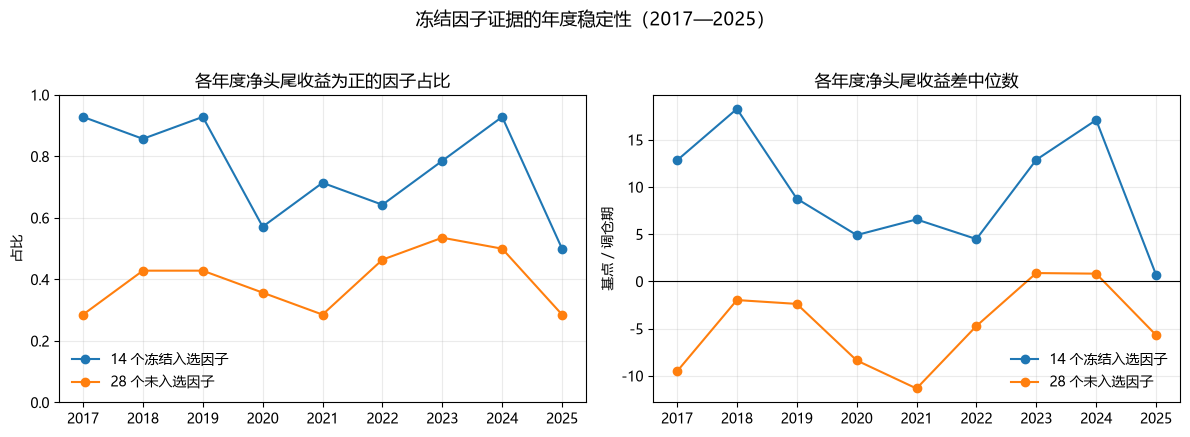

,组别,因子数,净收益为正因子数,净收益为正占比,净头尾收益差中位数_bps
0,全部 42 个,42,15,35.7%,-2.33
1,冻结入选 14 个,14,7,50.0%,0.71


In [5]:
yearly_joined = yearly.merge(factor_summary[["factor", "eligible"]], on="factor", how="left")
yearly_grouped = yearly_joined.groupby(["year", "eligible"], as_index=False).agg(
    平均覆盖率=("mean_coverage", "mean"),
    正净收益因子占比=("mean_q5_minus_q1_net", lambda x: (x > 0).mean()),
    净头尾收益差中位数=("mean_q5_minus_q1_net", "median"),
)
yearly_grouped["净头尾收益差中位数_bps"] = yearly_grouped["净头尾收益差中位数"] * 10_000
yearly_grouped["组别"] = np.where(
    yearly_grouped["eligible"], "14 个冻结入选因子", "28 个未入选因子"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for label, part in yearly_grouped.groupby("组别"):
    axes[0].plot(part["year"].astype(int), part["正净收益因子占比"], marker="o", label=label)
    axes[1].plot(part["year"].astype(int), part["净头尾收益差中位数_bps"], marker="o", label=label)
axes[0].set_title("各年度净头尾收益为正的因子占比")
axes[0].set_ylabel("占比")
axes[0].set_ylim(0, 1)
axes[1].set_title("各年度净头尾收益差中位数")
axes[1].set_ylabel("基点 / 调仓期")
axes[1].axhline(0, color="black", linewidth=0.8)
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
fig.suptitle("冻结因子证据的年度稳定性（2017—2025）", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

year_2025 = yearly_joined[yearly_joined["year"].astype(str).eq("2025")]
year_2025_summary = pd.DataFrame(
    [
        {
            "组别": label,
            "因子数": len(part),
            "净收益为正因子数": int((part["mean_q5_minus_q1_net"] > 0).sum()),
            "净收益为正占比": (part["mean_q5_minus_q1_net"] > 0).mean(),
            "净头尾收益差中位数_bps": part["mean_q5_minus_q1_net"].median() * 10_000,
        }
        for label, part in [
            ("全部 42 个", year_2025),
            ("冻结入选 14 个", year_2025[year_2025["eligible"]]),
        ]
    ]
)
display(
    year_2025_summary.style.format({"净收益为正占比": "{:.1%}", "净头尾收益差中位数_bps": "{:.2f}"})
)

## 5. 因子冗余

以下使用正式审计的全样本截面秩相关矩阵。绝对相关系数不低于 0.75 的因子被连成同一相关簇；簇数只用于描述信息冗余，不参与事后选参。


In [6]:
correlation = pd.read_parquet(AUDIT / "factor-correlation.parquet").set_index("factor")


def connected_components(selected, threshold=0.75):
    selected = list(selected)
    parent = {name: name for name in selected}

    def find(name):
        while parent[name] != name:
            parent[name] = parent[parent[name]]
            name = parent[name]
        return name

    def union(left, right):
        left_root, right_root = find(left), find(right)
        if left_root != right_root:
            parent[right_root] = left_root

    for index, left in enumerate(selected):
        for right in selected[index + 1 :]:
            if abs(float(correlation.loc[left, right])) >= threshold:
                union(left, right)
    groups = {}
    for name in selected:
        groups.setdefault(find(name), []).append(name)
    return sorted(groups.values(), key=lambda values: (-len(values), values))


all_clusters = connected_components(correlation.index)
eligible_names = factor_summary.loc[factor_summary["eligible"], "factor"]
eligible_clusters = connected_components(eligible_names)
cluster_summary = pd.DataFrame(
    [
        {
            "范围": "全部候选",
            "因子数": len(correlation),
            "相关簇数": len(all_clusters),
            "非单例簇数": sum(len(x) > 1 for x in all_clusters),
        },
        {
            "范围": "冻结入选",
            "因子数": len(eligible_names),
            "相关簇数": len(eligible_clusters),
            "非单例簇数": sum(len(x) > 1 for x in eligible_clusters),
        },
    ]
)
display(cluster_summary)
display(
    pd.DataFrame({"全部候选的非单例相关簇": [", ".join(x) for x in all_clusters if len(x) > 1]})
)
display(
    pd.DataFrame(
        {"冻结入选的非单例相关簇": [", ".join(x) for x in eligible_clusters if len(x) > 1]}
    )
)

,范围,因子数,相关簇数,非单例簇数
0,全部候选,42,30,7
1,冻结入选,14,12,1


,全部候选的非单例相关簇
0,"low_vol_20, low_downside_vol_60, low_range_vol..."
1,"cfo_yield_ttm, total_accruals_ttm, cash_conver..."
2,"roe_ttm, roa_ttm, operating_margin_ttm"
3,"book_to_price, book_to_market"
4,"earnings_growth_ttm_yoy, roe_change_yoy"
5,"reversal_20d, momentum_20_5"
6,"total_size, free_float_ratio"


,冻结入选的非单例相关簇
0,"low_idio_vol_60, low_downside_vol_60, low_rang..."


## 6. 新信息源进入 v2 的准备度

API 权限核对来自 Tushare 官方文档：`moneyflow` 与 `margin_detail` 在 2000 积分层可访问；`forecast` 的 2000 积分接口按证券查询，按报告期批量查询的 VIP 接口需要更高权限；Tushare 独立因子库为单独权限。这里不把权限等同于已完成的数据合同。


,信息源,已完成控制,结论
0,行情、成交量与复权,5,冻结 v2 可用
1,估值、换手与市值,5,冻结 v2 可用
2,财务报表与财务指标,5,冻结 v2 可用
3,成分、行业与交易状态,5,冻结 v2 可用
4,订单资金流 moneyflow,0,post-v2 候选
5,融资融券 margin_detail,0,post-v2 候选
6,业绩预告与快报,0,post-v2 候选
7,Tushare 独立因子库,0,不作为依赖


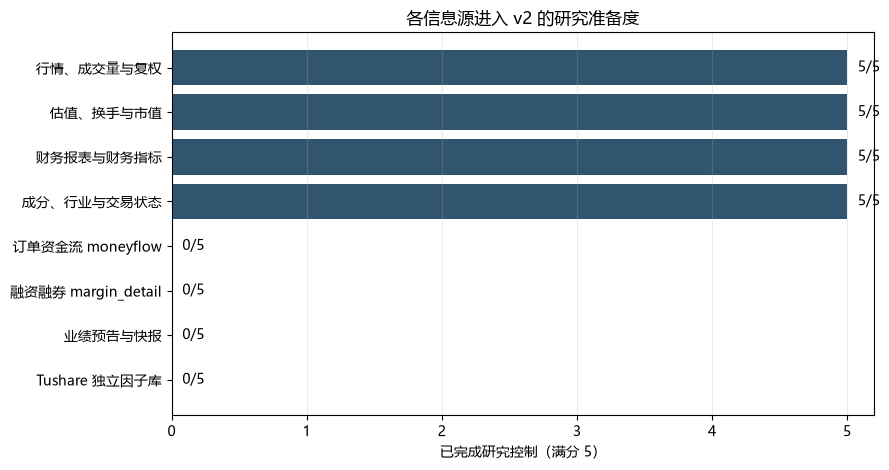

In [7]:
controls = ["本地缓存", "覆盖验证", "时点合同", "特征接口", "正式审计"]
source_readiness = pd.DataFrame(
    [
        ["行情、成交量与复权", True, True, True, True, True, "冻结 v2 可用"],
        ["估值、换手与市值", True, True, True, True, True, "冻结 v2 可用"],
        ["财务报表与财务指标", True, True, True, True, True, "冻结 v2 可用"],
        ["成分、行业与交易状态", True, True, True, True, True, "冻结 v2 可用"],
        ["订单资金流 moneyflow", False, False, False, False, False, "post-v2 候选"],
        ["融资融券 margin_detail", False, False, False, False, False, "post-v2 候选"],
        ["业绩预告与快报", False, False, False, False, False, "post-v2 候选"],
        ["Tushare 独立因子库", False, False, False, False, False, "不作为依赖"],
    ],
    columns=["信息源", *controls, "结论"],
)
source_readiness["已完成控制"] = source_readiness[controls].sum(axis=1)
display(
    source_readiness[["信息源", "已完成控制", "结论"]].style.bar(
        subset=["已完成控制"], vmin=0, vmax=5, color="#6a8caf"
    )
)

fig, ax = plt.subplots(figsize=(9, 4.8))
ordered = source_readiness.sort_values("已完成控制")
colors = ["#31556f" if value == 5 else "#b8c0c8" for value in ordered["已完成控制"]]
ax.barh(ordered["信息源"], ordered["已完成控制"], color=colors)
ax.set_xlim(0, 5.2)
ax.set_xlabel("已完成研究控制（满分 5）")
ax.set_title("各信息源进入 v2 的研究准备度")
ax.grid(axis="x", alpha=0.25)
for index, value in enumerate(ordered["已完成控制"]):
    ax.text(value + 0.08, index, f"{int(value)}/5", va="center")
plt.tight_layout()
plt.show()

## 7. 结论与开发门禁

**结论：立即冻结 v2；继续研究，但不再让新增因子改变 v2 权重。**

- 现有行情、估值、换手、财务、成分和行业数据足以支持当前因子池的可信回测。主键、覆盖和时点检查均表明，当前收益上限不能归因于底层数据质量失败。
- 现有 42 因子主要来自同一批价量、估值和财务信息。14 个入选因子仍包含低风险与现金流相关簇；2025 年只有 7/14 的净头尾收益差为正，说明主要瓶颈是信息源宽度、近期稳定性和交易翻译，而不是缺失值。
- 资金流、两融和公告数据虽然部分接口权限可用，但五项本地研究控制均未完成。现在接入会把 v2 从模型收尾重新变成数据工程项目，并引入无法在截止日前充分验证的自由度。
- A3.2 在 2020 开发折中 11 次有效拟合都把候选袖套权重收缩为 0，最终严格退化为 A0。这应如实记录为保护机制生效，不应继续打开 2021—2025 来追逐正结果。

**冻结规则**

1. v2 的数据指纹、42 因子候选域、筛选规则、组合权重方法、风险模型、成本和约束全部冻结。
2. v2 报告只引用现有 A0 与已完成消融；A3、A3.1、A3.2 均作为未晋级研究证据。
3. 新增因子进入 `post-v2` 候选通道；只有五项控制全部完成，才允许做独立的时序折外实验。
4. 在发布前只允许修复错误、补充复现说明和聚合展示，不再进行影响收益结果的参数搜索。

**局限**：本审计验证本地数据合同和研究制品的一致性，没有用第二供应商逐行核对 Tushare 原始数据；2021—2025 已参与现有 v2 因子审计，不能重新包装成全新的样本外证据。
